# Tensors, and the operations layers are made of

Rank, shape, dtype; broadcasting; the dot product; and the geometric reading of what a Dense layer does to a space.

**Runs on:** CPU — under a minute &nbsp;·&nbsp; **Slides:** [Chapter 2 — The Mathematical Building Blocks of Neural Networks](../../../course-web-slides/ch02/index.html) &nbsp;·&nbsp; **Section:** 02 — Data representations and tensor operations

---

## Rank, shape, dtype

In [8]:
import numpy as np

scalar = np.array(12)
vector = np.array([12, 3, 6, 14, 7])
matrix = np.array([[5, 78, 2], [6, 79, 3], [7, 80, 4]])

for name, t in [("scalar", scalar), ("vector", vector), ("matrix", matrix)]:
    print(f"{name:8s} ndim={t.ndim}  shape={t.shape}  dtype={t.dtype}")

scalar   ndim=0  shape=()  dtype=int64
vector   ndim=1  shape=(5,)  dtype=int64
matrix   ndim=2  shape=(3, 3)  dtype=int64


Expected output:

```
scalar   ndim=0  shape=()  dtype=int64
vector   ndim=1  shape=(5,)  dtype=int64
matrix   ndim=2  shape=(3, 3)  dtype=int64
```

> **Note** — A vector of five entries is a **5-dimensional vector** and a **rank-1 tensor**. Those two uses of *dimension* are different things and the confusion between them is worth killing early.

## The shapes you will actually meet

In [9]:
from keras.datasets import mnist
(train_images, _), _ = mnist.load_data()

print("images     ", train_images.shape, "  (samples, height, width)")
print("timeseries ", (256, 200, 5), "  (samples, timesteps, features)")
print("video      ", (4, 120, 144, 256, 3), "  (samples, frames, h, w, channels)")

images      (60000, 28, 28)   (samples, height, width)
timeseries  (256, 200, 5)   (samples, timesteps, features)
video       (4, 120, 144, 256, 3)   (samples, frames, h, w, channels)


## Slicing is how batches are made

In [10]:
batch = train_images[:128]
print("first batch:", batch.shape)

n = 3
print(f"batch {n}:", train_images[128 * n:128 * (n + 1)].shape)

# Axis 0 is always the samples axis. Every other axis belongs to one sample.
print("bottom-right quadrant of the first image:",
      train_images[0, 14:, 14:].shape)

first batch: (128, 28, 28)
batch 3: (128, 28, 28)
bottom-right quadrant of the first image: (14, 14)


## Element-wise operations, written out and then not

`relu` and addition are element-wise. Written as loops they are clear and slow; NumPy dispatches the same thing to BLAS.

In [11]:
def naive_relu(x):
    assert len(x.shape) == 2
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] = max(x[i, j], 0)
    return x

import time
x = np.random.random((2000, 1000)) - 0.5

t0 = time.time(); naive_relu(x); slow = time.time() - t0
t0 = time.time(); np.maximum(x, 0.0); fast = time.time() - t0
print(f"loop:  {slow:.3f}s\nnumpy: {fast:.5f}s\nratio: {slow/fast:.0f}x")

loop:  0.964s
numpy: 0.00355s
ratio: 272x


Expected output:

```
ratio: several hundred x
```

## Broadcasting

The smaller tensor is treated as if it were repeated along the missing axes — without actually being repeated, which is the point.

In [12]:
X = np.random.random((32, 10))
b = np.random.random((10,))

print("X + b ->", (X + b).shape)

# What broadcasting is doing, made explicit:
B = np.tile(b[np.newaxis, :], (32, 1))
print("identical to the explicit tile:", np.allclose(X + b, X + B))

X + b -> (32, 10)
identical to the explicit tile: True


## The dot product is the layer

In [13]:
def naive_matrix_vector_dot(x, y):
    z = np.zeros(x.shape[0])
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            z[i] += x[i, j] * y[j]
    return z

W = np.random.random((3, 4))
v = np.random.random((4,))
print(np.allclose(naive_matrix_vector_dot(W, v), W @ v))

# Shape compatibility is the only rule: (a, b) . (b, c) -> (a, c)
print((np.zeros((64, 3, 32, 10)) @ np.zeros((10, 7))).shape)

True
(64, 3, 32, 7)


## What a Dense layer does to a space

`output = relu(dot(input, W) + b)` is: a linear transform, a translation, then a fold. Here is that sequence applied to a grid, so the geometry is visible rather than asserted.

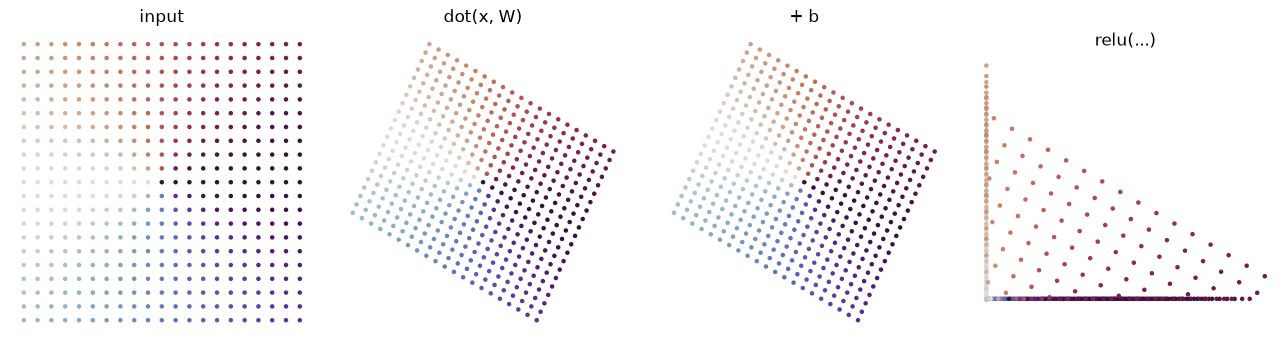

In [14]:
import matplotlib.pyplot as plt

g = np.stack(np.meshgrid(np.linspace(-1, 1, 21), np.linspace(-1, 1, 21)), -1)
pts = g.reshape(-1, 2)

W2 = np.array([[1.2, -0.7], [0.5, 1.1]])
b2 = np.array([0.15, -0.25])

stages = [
    ("input", pts),
    ("dot(x, W)", pts @ W2),
    ("+ b", pts @ W2 + b2),
    ("relu(...)", np.maximum(pts @ W2 + b2, 0)),
]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, (name, p) in zip(axes, stages):
    ax.scatter(p[:, 0], p[:, 1], s=5, c=np.arctan2(pts[:, 1], pts[:, 0]), cmap="twilight")
    ax.set_title(name); ax.set_aspect("equal"); ax.axis("off")
plt.tight_layout(); plt.show()

The last panel is the one that matters: `relu` **collapses** a whole region onto the axes. That is the nonlinearity, and it is why stacking layers buys you something that one layer cannot do.

---

## What to take away

- Rank, shape, and dtype describe every tensor you will meet; axis 0 is always the samples axis.
- Element-wise operations, broadcasting, and the dot product are the whole vocabulary of a Dense layer.
- Broadcasting repeats **conceptually**, not in memory.
- A layer is an affine transform followed by a fold — geometry, not magic.